# Enhanced PhenoAge Model - Prototype Implementation

This notebook demonstrates a prototype implementation of the proposed enhanced PhenoAge framework.

The objective is not to reproduce the original PhenoAge algorithm but to illustrate how additional biomarkers and lifestyle variables could be integrated into a predictive model using modern machine learning techniques.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

In [2]:
n = 500

data = pd.DataFrame({
    "Age": np.random.randint(40, 90, n),
    "Albumin": np.random.normal(4.2, 0.4, n),
    "Creatinine": np.random.normal(1.0, 0.2, n),
    "CRP": np.random.normal(2.5, 1.2, n),
    "HbA1c": np.random.normal(5.8, 0.6, n),
    "IL6": np.random.normal(2.0, 0.8, n),
    "ApoB": np.random.normal(100, 20, n),
    "GDF15": np.random.normal(900, 180, n),
    "Sleep": np.random.normal(7.2, 0.8, n),
    "Exercise": np.random.normal(4, 2, n)
})

data.head()

,Age,Albumin,Creatinine,CRP,HbA1c,IL6,ApoB,GDF15,Sleep,Exercise
0,78,2.903493,1.512017,3.146507,5.845260,2.988626,117.907109,737.169413,6.549589,5.519030
1,68,3.790245,0.980788,1.395192,4.838821,1.143157,87.368445,1111.096232,7.858624,3.416483
2,54,4.098973,1.229855,2.703233,5.652363,2.544173,105.063305,1019.775028,7.380609,3.880348
3,82,3.700887,0.859365,0.803543,5.294052,2.954006,116.406880,1249.419139,7.214091,4.987120
4,47,4.852965,0.993002,2.366529,7.102566,0.577130,99.327749,741.901846,6.419707,4.581794


In [3]:
data["BioAge"] = (
    0.35 * data["Age"] +
    2.0 * data["CRP"] +
    1.5 * data["HbA1c"] +
    0.02 * data["ApoB"] +
    0.005 * data["GDF15"] -
    0.5 * data["Albumin"] -
    0.3 * data["Sleep"] -
    0.4 * data["Exercise"] +
    np.random.normal(0, 3, len(data))
)

data.head()

,Age,Albumin,Creatinine,CRP,HbA1c,IL6,ApoB,GDF15,Sleep,Exercise,BioAge
0,78,2.903493,1.512017,3.146507,5.845260,2.988626,117.907109,737.169413,6.549589,5.519030,44.796493
1,68,3.790245,0.980788,1.395192,4.838821,1.143157,87.368445,1111.096232,7.858624,3.416483,36.684768
2,54,4.098973,1.229855,2.703233,5.652363,2.544173,105.063305,1019.775028,7.380609,3.880348,31.186057
3,82,3.700887,0.859365,0.803543,5.294052,2.954006,116.406880,1249.419139,7.214091,4.987120,41.562522
4,47,4.852965,0.993002,2.366529,7.102566,0.577130,99.327749,741.901846,6.419707,4.581794,27.798689


In [4]:
from sklearn.model_selection import train_test_split

X = data.drop(columns="BioAge")
y = data["BioAge"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.33,-0.55,-0.29,..., 0. ,-0.21,-0.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['Age','Albumin','Creatinine',...,'GDF15','Sleep','Exercise']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.4295
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [6]:
pred = model.predict(X_test)

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, pred))
print("R²:", r2_score(y_test, pred))

MAE: 2.3679439831714064
R²: 0.7460429697672026


In [8]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
3,CRP,2.078065
4,HbA1c,1.807293
0,Age,0.326690
6,ApoB,0.018196
7,GDF15,0.004274
5,IL6,-0.099139
8,Sleep,-0.210586
2,Creatinine,-0.293112
9,Exercise,-0.397007
1,Albumin,-0.545601


In [9]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)

elastic.fit(X_train, y_train)

pred_elastic = elastic.predict(X_test)

print("Elastic Net")
print("MAE:", mean_absolute_error(y_test, pred_elastic))
print("R²:", r2_score(y_test, pred_elastic))

Elastic Net
MAE: 2.3312489601753015
R²: 0.7531705900435179


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R²:", r2_score(y_test, pred_rf))

Random Forest
MAE: 2.521572177524909
R²: 0.7094985447487254


In [11]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Elastic Net",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, pred),
        mean_absolute_error(y_test, pred_elastic),
        mean_absolute_error(y_test, pred_rf)
    ],
    "R2": [
        r2_score(y_test, pred),
        r2_score(y_test, pred_elastic),
        r2_score(y_test, pred_rf)
    ]
})

results

,Model,MAE,R2
0,Linear Regression,2.367944,0.746043
1,Elastic Net,2.331249,0.753171
2,Random Forest,2.521572,0.709499


In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Age,0.554824
3,CRP,0.193916
4,HbA1c,0.042861
9,Exercise,0.041298
7,GDF15,0.041101
6,ApoB,0.028021
2,Creatinine,0.026023
8,Sleep,0.025666
5,IL6,0.024809
1,Albumin,0.021481


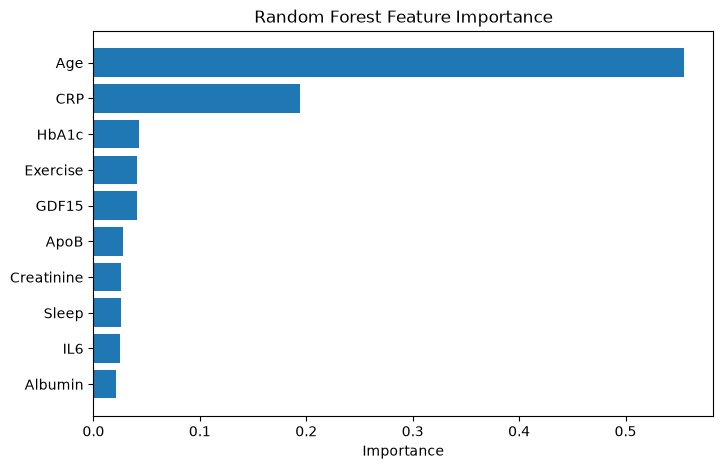

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

# Prototype Summary

Three machine learning approaches were evaluated using a simulated dataset representing clinical biomarkers and lifestyle variables.

The Linear Regression model provides a simple and interpretable baseline.

Elastic Net introduces regularisation, reducing the risk of overfitting while handling correlated biomarkers.

Random Forest captures nonlinear relationships and interactions between biomarkers, providing feature importance estimates that help identify the most influential predictors.

This prototype demonstrates how an enhanced PhenoAge framework could be implemented and evaluated using modern machine learning methods. Future work should validate the model using real-world clinical datasets and compare its performance with established biological age predictors.

In [14]:
results.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Saved: outputs/model_comparison.csv")

OSError: Cannot save file into a non-existent directory: '..\outputs'

In [15]:
from pathlib import Path

print(Path.cwd())

C:\Users\PC\PhenoAge-Enhanced


In [16]:
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

results.to_csv(
    output_dir / "model_comparison.csv",
    index=False
)

print("Saved:", output_dir / "model_comparison.csv")

Saved: outputs\model_comparison.csv


In [17]:
importance.to_csv(
    output_dir / "random_forest_feature_importance.csv",
    index=False
)

print("Saved:", output_dir / "random_forest_feature_importance.csv")

Saved: outputs\random_forest_feature_importance.csv


In [18]:
figure_dir = Path("figures")
figure_dir.mkdir(parents=True, exist_ok=True)

In [19]:
plt.savefig(
    figure_dir / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [20]:
output_dir = Path("../outputs")
figure_dir = Path("../figures")

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

In [21]:
from pathlib import Path

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_dir = current_dir.parent
else:
    project_dir = current_dir

output_dir = project_dir / "outputs"
figure_dir = project_dir / "figures"

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

results.to_csv(
    output_dir / "model_comparison.csv",
    index=False
)

importance.to_csv(
    output_dir / "random_forest_feature_importance.csv",
    index=False
)

print("Results saved to:", output_dir)
print("Figures will be saved to:", figure_dir)

Results saved to: C:\Users\PC\PhenoAge-Enhanced\outputs
Figures will be saved to: C:\Users\PC\PhenoAge-Enhanced\figures


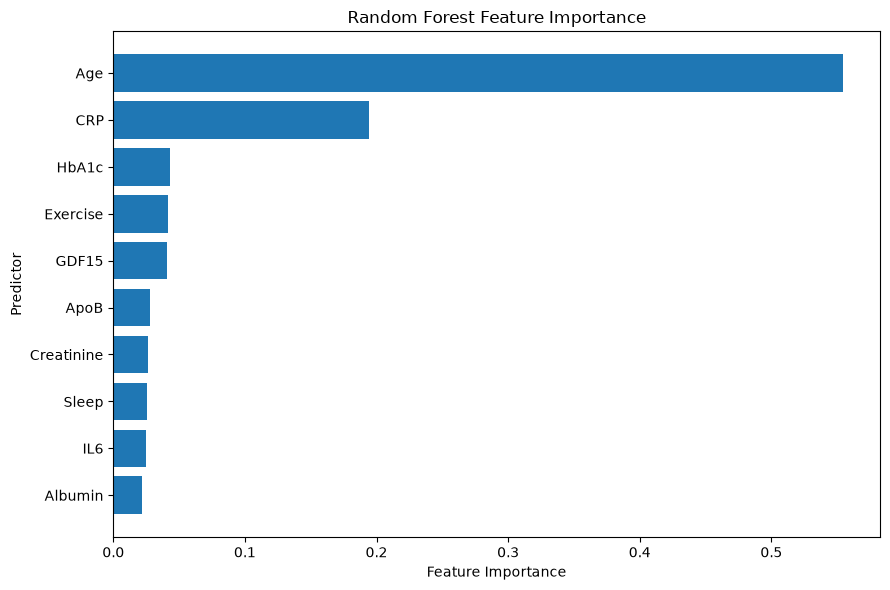

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    figure_dir / "random_forest_feature_importance.png",
    dpi=300
)

plt.show()

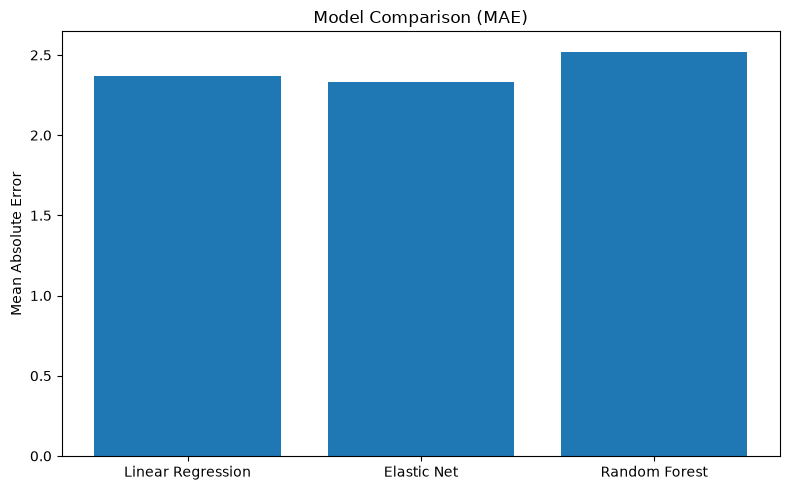

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.ylabel("Mean Absolute Error")
plt.title("Model Comparison (MAE)")

plt.tight_layout()

plt.savefig(
    figure_dir / "model_comparison_mae.png",
    dpi=300
)

plt.show()

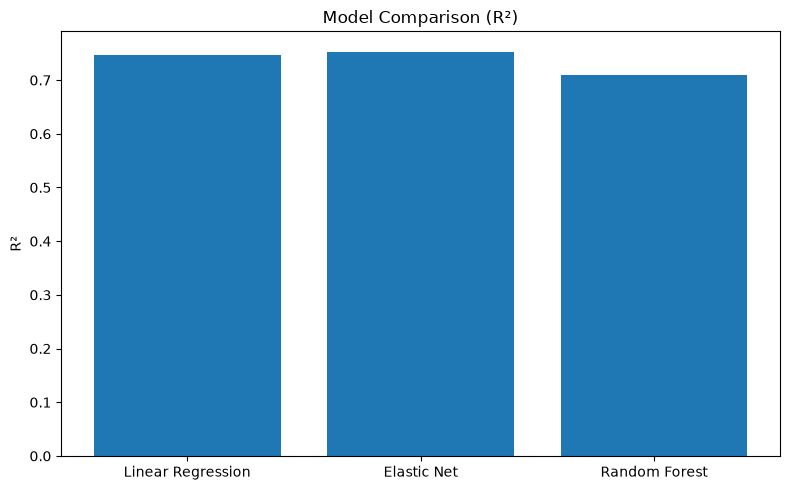

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["R2"]
)

plt.ylabel("R²")
plt.title("Model Comparison (R²)")

plt.tight_layout()

plt.savefig(
    figure_dir / "model_comparison_r2.png",
    dpi=300
)

plt.show()

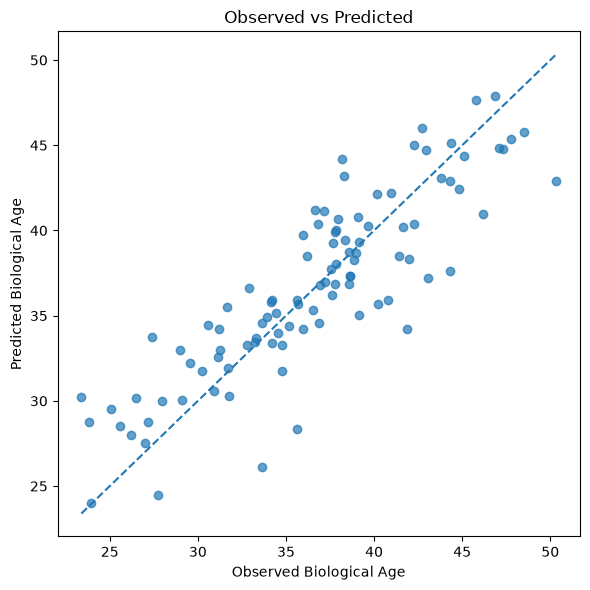

In [25]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.xlabel("Observed Biological Age")
plt.ylabel("Predicted Biological Age")
plt.title("Observed vs Predicted")

plt.tight_layout()

plt.savefig(
    figure_dir / "observed_vs_predicted.png",
    dpi=300
)

plt.show()